<a href="https://colab.research.google.com/github/gkambasta/TimeSeries/blob/main/Random_Walk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AI Code**

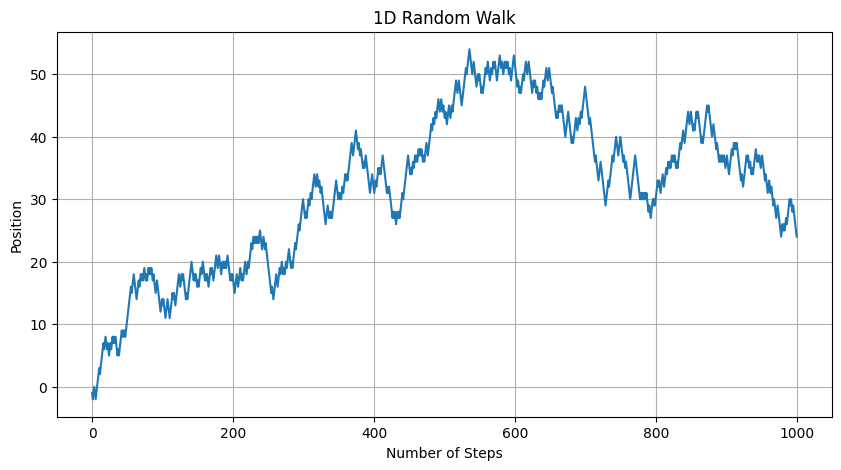

In [98]:

import numpy as np
import matplotlib.pyplot as plt

def random_walk_1d(n_steps):
    # Randomly choose steps: -1 or 1
    steps = np.random.choice([-1, 1], size=n_steps)
    # Calculate position as the cumulative sum of steps
    path = np.cumsum(steps)
    return path

# Simulation
steps = 1000
path = random_walk_1d(steps)

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(path)
plt.title("1D Random Walk")
plt.xlabel("Number of Steps")
plt.ylabel("Position")
plt.grid(True)
plt.show()

### 1D Random Walk Visualization with Seaborn

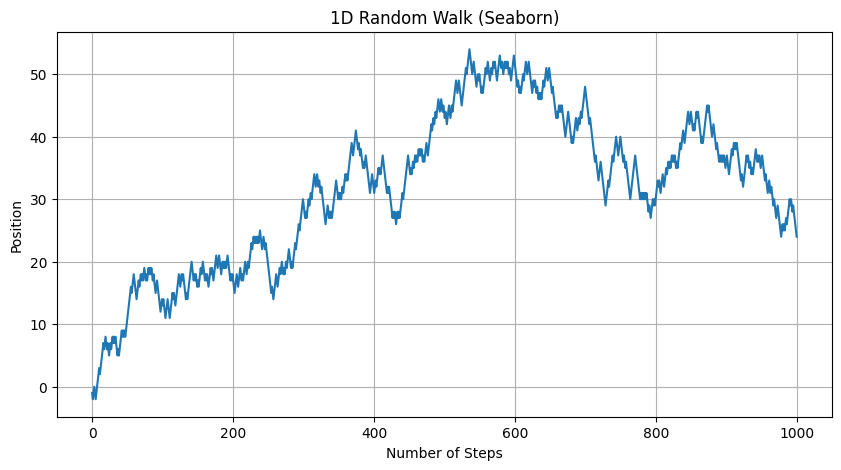

In [99]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(x=range(len(path)), y=path)
plt.title("1D Random Walk (Seaborn)")
plt.xlabel("Number of Steps")
plt.ylabel("Position")
plt.grid(True)
plt.show()

### 1D Random Walk Visualization with Plotly

In [100]:
import plotly.graph_objects as go

# The 'path' variable for the 1D random walk is already available from previous execution

fig = go.Figure(
    data=[
        go.Scatter(
            x=list(range(len(path))),
            y=path,
            mode='lines',
            name='1D Random Walk Path',
            line=dict(color='purple', width=1)
        )
    ],
    layout=go.Layout(
        title=go.layout.Title(text="1D Random Walk (Plotly)"),
        xaxis=dict(title='Number of Steps'),
        yaxis=dict(title='Position'),
        showlegend=False
    )
)

fig.show()

### Simulating a Stationary Time Series (AR(1) Process)

A stationary time series is one whose statistical properties (like mean, variance, and autocorrelation) do not change over time. A common way to simulate a stationary series is using an Autoregressive (AR) process. Here, we'll simulate an AR(1) process, where the current value depends linearly on its own previous value plus a random error term.

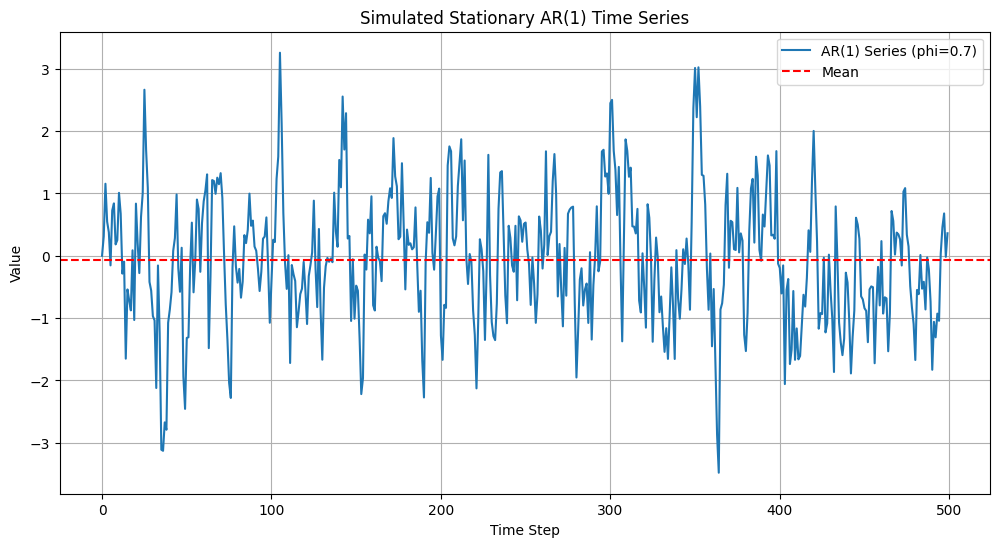

In [101]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ar1_series(n_steps, phi=0.5, sigma=1.0):
    """
    Simulates a stationary AR(1) time series.

    Args:
        n_steps (int): The number of steps/observations in the series.
        phi (float): The autoregressive coefficient. For stationarity, |phi| < 1.
        sigma (float): The standard deviation of the white noise error term.

    Returns:
        numpy.ndarray: The simulated AR(1) time series.
    """
    # Initialize the series with a starting value (e.g., 0)
    series = np.zeros(n_steps)
    # Generate white noise errors
    errors = np.random.normal(loc=0, scale=sigma, size=n_steps)

    # Simulate the AR(1) process: Xt = phi * Xt-1 + Et
    for i in range(1, n_steps):
        series[i] = phi * series[i-1] + errors[i]

    return series

# Simulation parameters
n_observations = 500
phi_coefficient = 0.7  # For stationarity, |phi| < 1
noise_std = 0.8

# Simulate the stationary AR(1) series
stationary_series = simulate_ar1_series(n_observations, phi=phi_coefficient, sigma=noise_std)

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(stationary_series, label=f'AR(1) Series (phi={phi_coefficient})')
plt.title("Simulated Stationary AR(1) Time Series")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.axhline(np.mean(stationary_series), color='red', linestyle='--', label='Mean')
plt.grid(True)
plt.legend()
plt.show()

### Simulating a Non-Stationary Time Series (Random Walk with Drift)

A non-stationary time series is one whose statistical properties (like mean, variance, or autocorrelation) change over time. A classic example is a random walk with a drift, where the series tends to move in a particular direction over time.

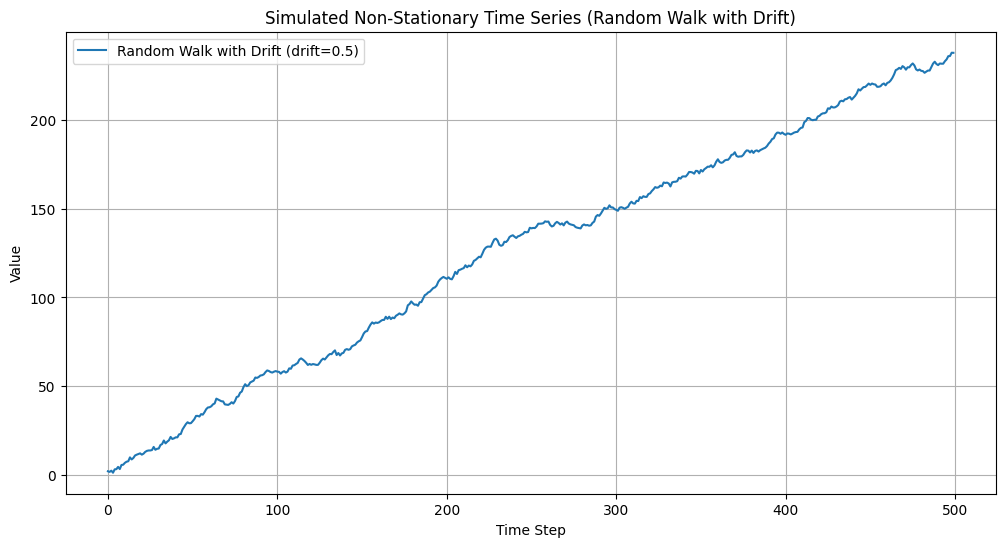

In [102]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_random_walk_with_drift(n_steps, drift=0.1, sigma=1.0):
    """
    Simulates a non-stationary random walk with a drift.

    Args:
        n_steps (int): The number of steps/observations in the series.
        drift (float): The constant value added at each step (the 'drift').
        sigma (float): The standard deviation of the random noise.

    Returns:
        numpy.ndarray: The simulated random walk with drift series.
    """
    # Generate random steps from a normal distribution
    steps = np.random.normal(loc=drift, scale=sigma, size=n_steps)
    # Calculate the path as the cumulative sum of steps
    series = np.cumsum(steps)
    return series

# Simulation parameters
n_observations_non_stationary = 500
drift_value = 0.5  # Positive drift
noise_std_non_stationary = 1.0

# Simulate the non-stationary series
non_stationary_series = simulate_random_walk_with_drift(n_observations_non_stationary, drift=drift_value, sigma=noise_std_non_stationary)

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(non_stationary_series, label=f'Random Walk with Drift (drift={drift_value})')
plt.title("Simulated Non-Stationary Time Series (Random Walk with Drift)")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

**Manual Code**

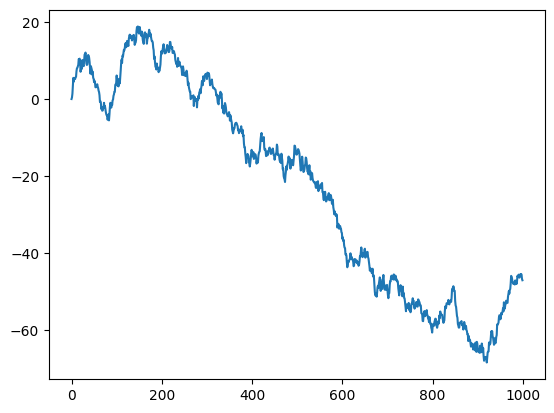

In [103]:
np.random.seed(0)
steps = np.random.standard_normal(1000)
steps[0] = 0
random_walk = np.cumsum(steps)
plt.plot(random_walk)

### ***With Drift***

In [104]:
C=.15
step2 = []

for i in range(len(steps)):
    if i == 0:
        step2.append(steps[i])
    else:
        step2.append(steps[i]+ C)



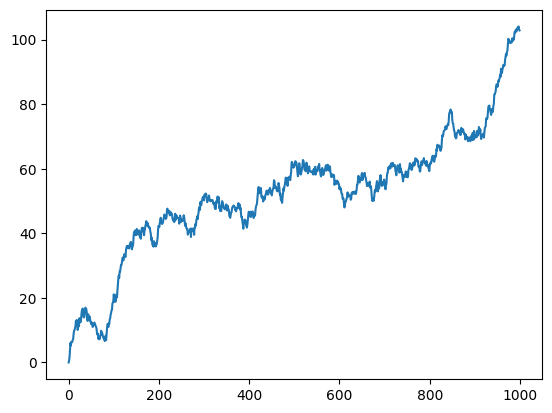

In [105]:
rand2 = np.cumsum(step2)
plt.plot(rand2)


Stationary vs non-stationary

In [106]:
def simulate_timeseries(is_stationary):
    np.random.seed(0)
    process = np.empty(1000)
    process[0] = 0


    if is_stationary:
        a = 0.8
    else:
        a = 1

    for i in range(len(process)):
        if i < 999:
            process[i+1] = a * process[i] + np.random.standard_normal()
        else:
            break

    #process[a * process[i] + np.random.standard_normal() for i in len(process)]

    return process




In [107]:
stationary = simulate_timeseries(True)
non_stationary = simulate_timeseries(False)


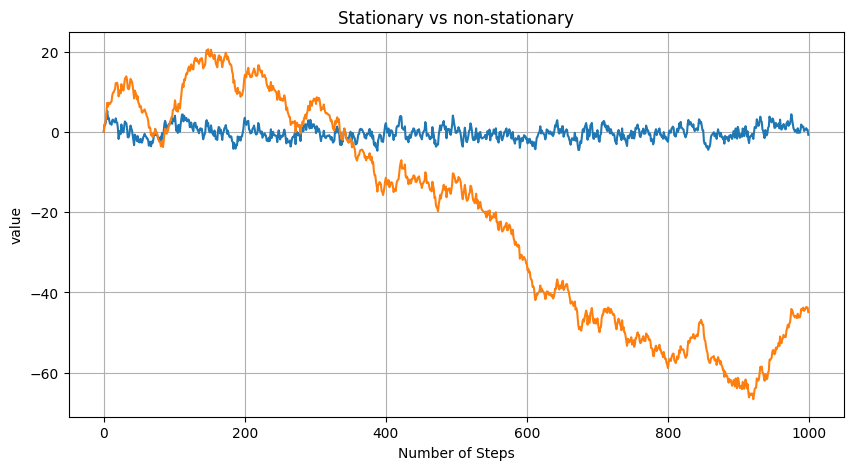

In [108]:
# Visualization
plt.figure(figsize=(10, 5))
plt.plot(stationary, label='Stationary')
plt.plot(non_stationary,label = 'non-stationary')
plt.title("Stationary vs non-stationary")
plt.xlabel("Number of Steps")
plt.ylabel("value")
plt.grid(True)
plt.show()

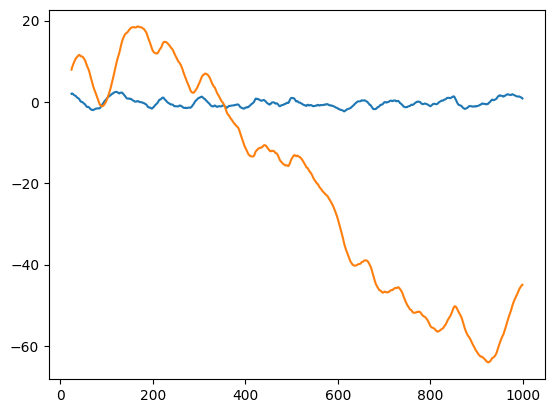

In [109]:
import pandas as pd
s = pd.DataFrame(stationary)
ns = pd.DataFrame(non_stationary)

plt.plot(s.rolling(window = 25).mean())
plt.plot(ns.rolling(window =25).mean())

In [110]:
stationary[1:10]

array([1.76405235, 1.81139909, 2.42785725, 4.183179  , 5.21410119,
       3.19400307, 3.50529088, 2.65287549, 2.01908154])

In [111]:
def mean_func(process):
    mean_lst = []
    for i in range(len(process)):
        mean_lst.append(np.mean(process[:i]))

    return mean_lst

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning:

Mean of empty slice.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning:

invalid value encountered in scalar divide



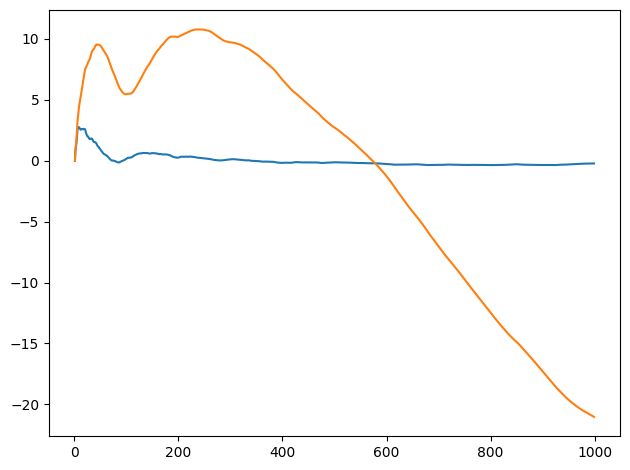

In [112]:
plt.plot(mean_func(stationary))
plt.plot(mean_func(non_stationary))

plt.tight_layout ()

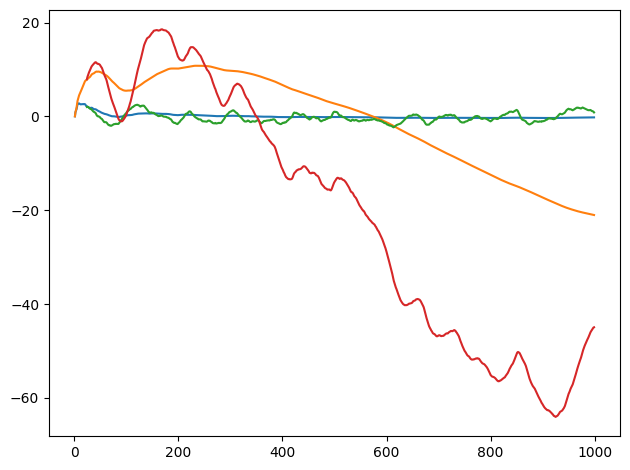

In [113]:
plt.plot(mean_func(stationary))
plt.plot(mean_func(non_stationary))
plt.plot(s.rolling(window = 25).mean())
plt.plot(ns.rolling(window =25).mean())


plt.tight_layout()

In [114]:
def simulate_timeseries_chk(is_stationary):
    np.random.seed(0)
    process = np.empty(1000)
    process[0] = 0


    if is_stationary:
        a = 0.8
    else:
        a = 1

    for i in range(len(process)):
        if i < 999:
            process[i+1] = a * process[i] + np.random.standard_normal()
        else:
            break

    #process[a * process[i] + np.random.standard_normal() for i in len(process)]

    return process




In [115]:
stationary2 = simulate_timeseries_chk(True)
non_stationary2 = simulate_timeseries_chk(False)

#

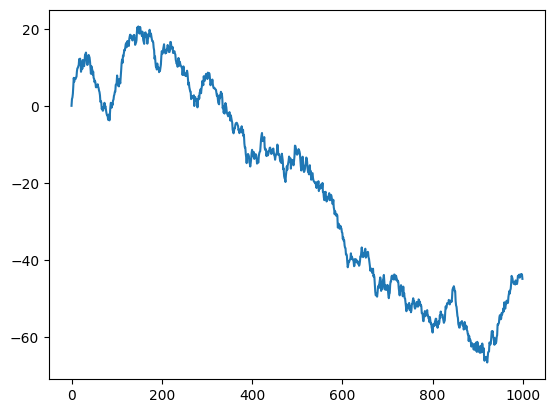

In [116]:
#plt.plot(stationary2[:400])
plt.plot(non_stationary2)

In [117]:
def var_func(process):
    var_lst = []
    for i in range(len(process)):
        var_lst.append(np.var(process[:i]))

    return var_lst

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning:

Degrees of freedom <= 0 for slice

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning:

invalid value encountered in scalar divide



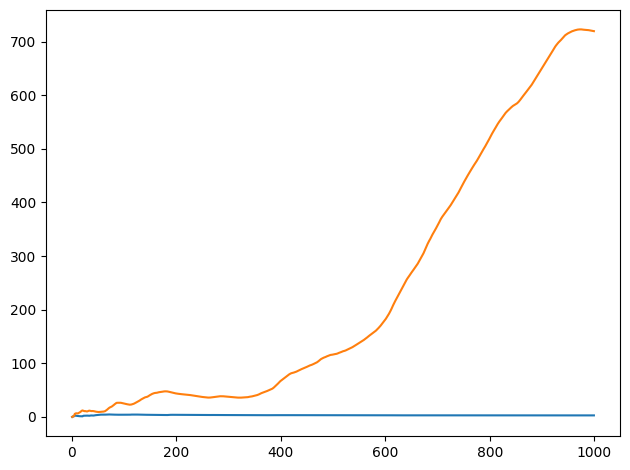

In [118]:
plt.plot(var_func(stationary))
plt.plot(var_func(non_stationary))

plt.tight_layout()

Text(0.5, 1.0, 'Top Plot: non_stationary')

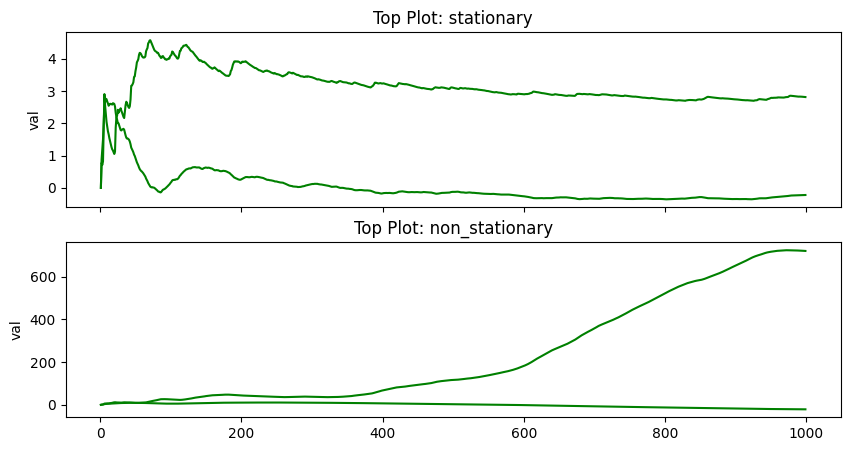

In [119]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax1.plot(mean_func(stationary), 'g')
ax1.plot(var_func(stationary), 'g')
ax1.set_ylabel('val')
ax1.set_title('Top Plot: stationary')

ax2.plot(mean_func(non_stationary), 'g')
ax2.plot(var_func(non_stationary), 'g')
ax2.set_ylabel('val')
ax2.set_title('Top Plot: non_stationary')

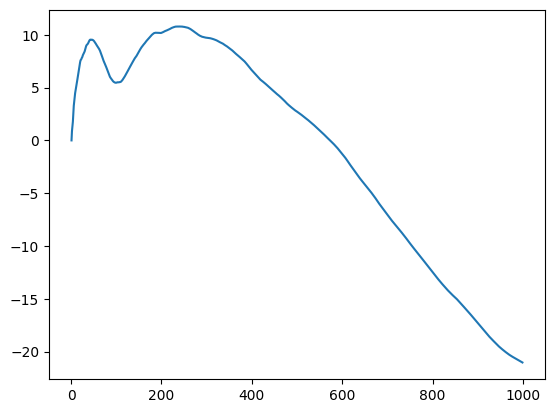

In [120]:
plt.plot(mean_func(non_stationary))

Text(0.5, 1.0, 'Stat vs non stat')

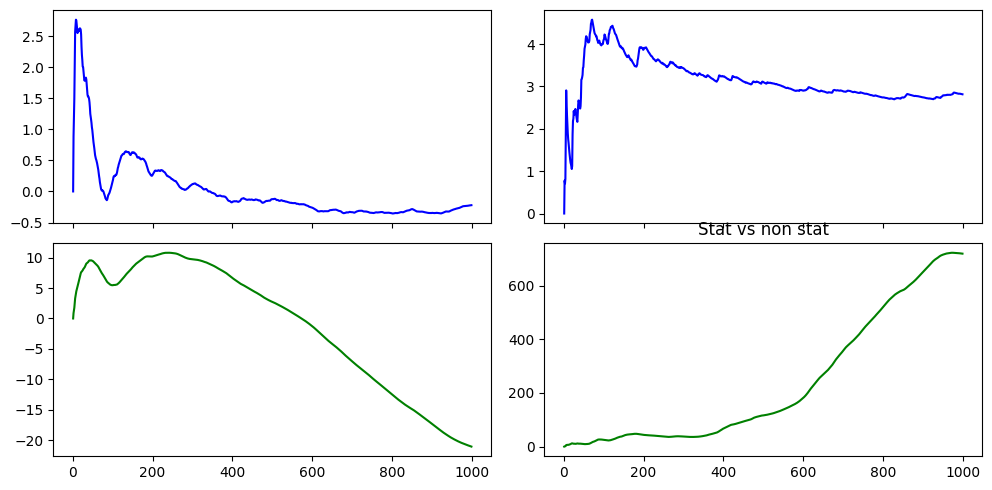

In [123]:
fig, ax = plt.subplots(2,2, figsize=(10, 5), sharex=True)

ax[0,0].plot(mean_func(stationary), 'b')
ax[0,1].plot(var_func(stationary), 'b')

ax[1,0].plot(mean_func(non_stationary), 'g')
ax[1,1].plot(var_func(non_stationary), 'g')

plt.tight_layout()
plt.title("Stat vs non stat")
#

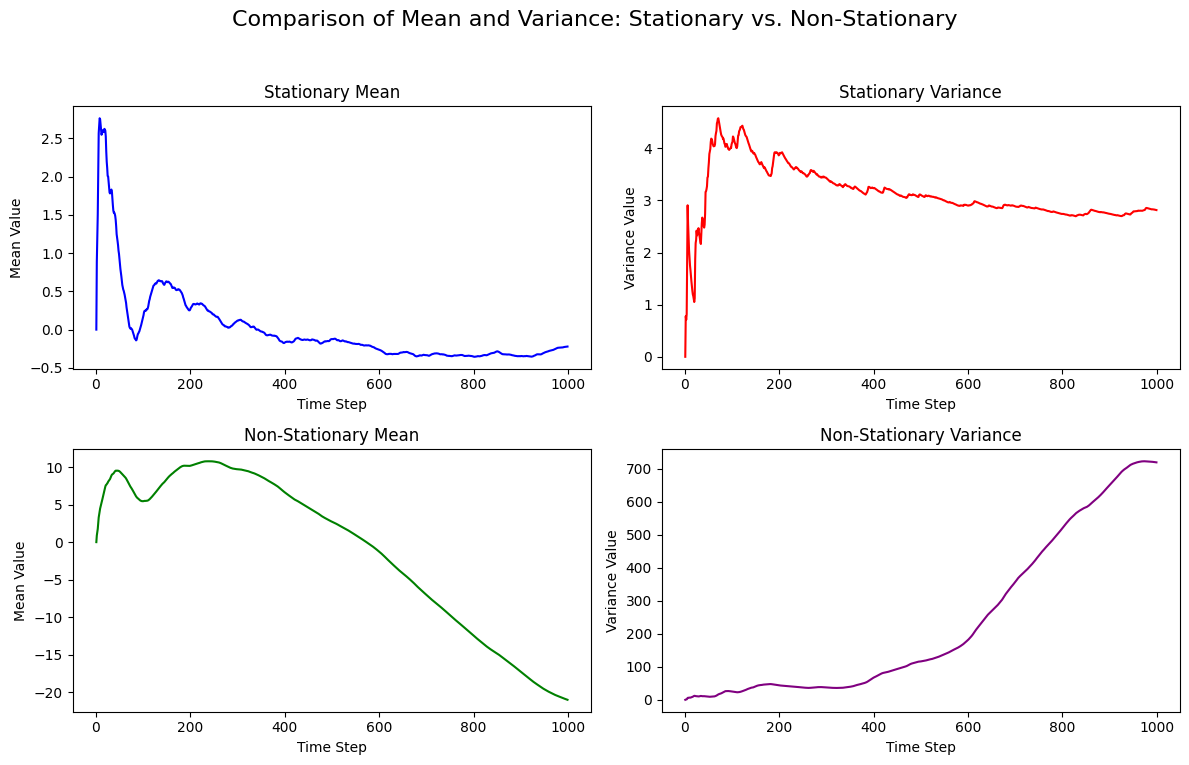

In [125]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(mean_func(stationary), 'b')
ax[0, 0].set_title('Stationary Mean')
ax[0, 0].set_xlabel('Time Step')
ax[0, 0].set_ylabel('Mean Value')

ax[0, 1].plot(var_func(stationary), 'r')
ax[0, 1].set_title('Stationary Variance')
ax[0, 1].set_xlabel('Time Step')
ax[0, 1].set_ylabel('Variance Value')

ax[1, 0].plot(mean_func(non_stationary), 'g')
ax[1, 0].set_title('Non-Stationary Mean')
ax[1, 0].set_xlabel('Time Step')
ax[1, 0].set_ylabel('Mean Value')

ax[1, 1].plot(var_func(non_stationary), 'purple')
ax[1, 1].set_title('Non-Stationary Variance')
ax[1, 1].set_xlabel('Time Step')
ax[1, 1].set_ylabel('Variance Value')

plt.suptitle('Comparison of Mean and Variance: Stationary vs. Non-Stationary', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()